# Notebook 08 — Vehicle & Fare Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Compare vehicle types on supply, demand, fares, service quality, and GBV.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/08_*`, tables in `outputs/reports/`  

> ⚠️ Only **Gross Booking Value (GBV)** is reported. Driver payout, commission, net margin
> are **unavailable** — no cost fields exist in the dataset.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 8.1 Supply & Demand by Vehicle Type

In [2]:
veh = df.groupby('Vehicle Type', observed=True).agg(
    total_bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    ndf=('Booking Status', lambda s: (s=='No Driver Found').sum()),
    cancelled_driver=('Booking Status', lambda s: (s=='Cancelled by Driver').sum()),
    cancelled_cust=('Booking Status', lambda s: (s=='Cancelled by Customer').sum()),
    avg_vtat=('Avg VTAT','mean'),
    avg_ctat=('Avg CTAT','mean'),
).round(2)
veh['completion_rate_pct'] = (veh['completed']/veh['total_bookings']*100).round(1)
veh['ndf_rate_pct']        = (veh['ndf']/veh['total_bookings']*100).round(1)
veh['drv_canc_rate_pct']   = (veh['cancelled_driver']/veh['total_bookings']*100).round(1)
veh['cust_canc_rate_pct']  = (veh['cancelled_cust']/veh['total_bookings']*100).round(1)
veh = veh.sort_values('total_bookings', ascending=False)
print(veh[['total_bookings','completion_rate_pct','ndf_rate_pct',
           'drv_canc_rate_pct','cust_canc_rate_pct','avg_vtat']].to_string())

               total_bookings  completion_rate_pct  ndf_rate_pct  drv_canc_rate_pct  cust_canc_rate_pct  avg_vtat
Vehicle Type                                                                                                     
Auto                    37419                 61.9           7.2               17.8                 7.2      8.45
Go Mini                 29806                 62.2           6.8               17.9                 7.0      8.47
Go Sedan                27141                 61.4           7.2               18.5                 6.7      8.40
Bike                    22517                 62.3           6.7               18.1                 7.0      8.50
Premier Sedan           18111                 62.1           7.1               17.9                 7.0      8.44
eBike                   10557                 62.1           7.1               18.1                 6.8      8.48
Uber XL                  4449                 62.6           7.1               17.1     

## 8.2 Fare Analysis

In [3]:
fare_stats = completed.groupby('Vehicle Type', observed=True)['Booking Value'].describe(
    percentiles=[0.25,0.5,0.75]).round(0)
print('Fare distribution by Vehicle Type (₹):')
print(fare_stats.to_string())

fpk = completed.groupby('Vehicle Type', observed=True)['fare_per_km'].mean().sort_values(ascending=False)
print(); print('Avg Fare/km by Vehicle Type (₹/km):'); print(fpk.round(2).to_string())

Fare distribution by Vehicle Type (₹):
                 count   mean    std   min    25%    50%    75%     max
Vehicle Type                                                           
Auto           23155.0  506.0  391.0  50.0  233.0  413.0  688.0  4220.0
Bike           14034.0  509.0  401.0  50.0  234.0  415.0  689.0  4228.0
Go Mini        18549.0  507.0  395.0  50.0  233.0  412.0  689.0  4277.0
Go Sedan       16676.0  512.0  397.0  50.0  236.0  417.0  694.0  4088.0
Premier Sedan  11252.0  510.0  396.0  50.0  237.0  417.0  691.0  4008.0
Uber XL         2783.0  505.0  394.0  50.0  238.0  411.0  683.0  3703.0
eBike           6551.0  503.0  405.0  50.0  226.0  409.0  673.0  4093.0

Avg Fare/km by Vehicle Type (₹/km):
Vehicle Type
Go Sedan         34.66
Auto             34.00
Bike             33.89
Uber XL          33.85
Premier Sedan    33.73
Go Mini          33.49
eBike            32.47


TypeError: Axes.boxplot() got an unexpected keyword argument 'order'. Did you mean 'zorder'?

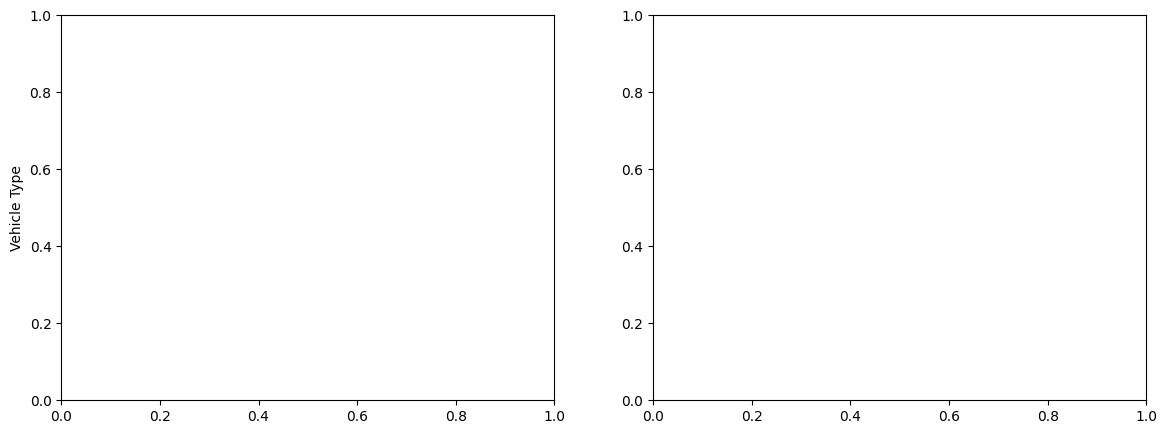

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vehicle_order = veh.index.tolist()
completed.boxplot(column='Booking Value', by='Vehicle Type', ax=axes[0],
                  order=vehicle_order, vert=False)
axes[0].set_title('Fare Distribution by Vehicle Type (₹)')
axes[0].set_xlabel('Booking Value (₹)')
plt.sca(axes[0]); plt.title('Fare Distribution by Vehicle Type (₹)')

fpk_s = completed.groupby('time_slot', observed=True)['Booking Value'].mean().reindex(
    [s for s in slot_order if s in df['time_slot'].cat.categories])
fpk_s.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avg Fare by Time Slot (₹)'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Fare Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/08_fare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.3 Service Quality per Vehicle

In [ ]:
sq = completed.groupby('Vehicle Type', observed=True).agg(
    avg_driver_rating=('Driver Ratings','mean'),
    avg_customer_rating=('Customer Rating','mean'),
    avg_ride_distance=('Ride Distance','mean'),
    avg_booking_value=('Booking Value','mean'),
    gbv=('Booking Value','sum'),
).round(2)
sq['gbv_per_completed_ride'] = (sq['gbv'] / veh['completed']).round(0)
print('Service Quality by Vehicle Type:')
print(sq.to_string())
sq.to_csv('outputs/reports/vehicle_service_quality.csv')
print('\nSaved: outputs/reports/vehicle_service_quality.csv')

## 8.4 Revenue by Vehicle (GBV Only)

In [ ]:
gbv_veh = completed.groupby('Vehicle Type', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('Gross Booking Value by Vehicle Type:')
print(gbv_veh.apply(lambda x: f'₹{x:,.0f}').to_string())
print()
print('NOTE: Net revenue, driver payout, commission, and margin CANNOT be calculated')
print('      from this dataset — no cost fields are present.')

fig, ax = plt.subplots(figsize=(8, 5))
gbv_veh.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Gross Booking Value by Vehicle Type\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('GBV (₹)'); ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.0f}M'))
plt.tight_layout()
fig.savefig('outputs/plots/08_gbv_by_vehicle.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- Net revenue, driver payout, commission, operating cost, and contribution margin are **unavailable**.
- Vehicle retirement recommendations require cost-side data not present in this dataset.